--------------------------------------------------
Resultados Finales en t = 480 s (con h=60s):
--------------------------------------------------
1. RK2 Ralston : 652.254787 K
2. RK4 Runge   : 647.539297 K
3. RK4 Kutta   : 647.443717 K
--------------------------------------------------


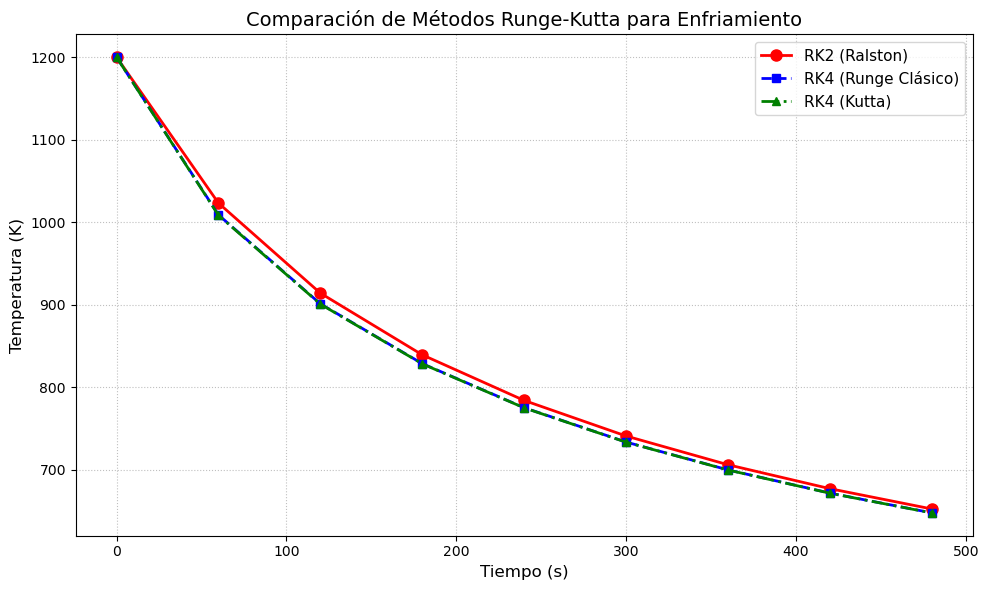

In [8]:
import matplotlib.pyplot as plt

# ==========================================
# FUNCIÓN DE LA ECUACIÓN DIFERENCIAL
# ==========================================
def f(t, theta):
    """
    Ecuación diferencial: d(theta)/dt = -A(theta^4 - B)
    """
    A = 2.2067e-12
    B = 8.1e9
    return -A * (theta**4 - B)

# ==========================================
# 1. MÉTODO DE RALSTON (RK2)
# ==========================================
def rk2_ralston(t0, theta0, h, t_final):
    t, theta = t0, theta0
    t_list, theta_list = [t], [theta]
    
    while round(t, 5) < round(t_final, 5):
        k1 = f(t, theta)
        k2 = f(t + 0.75*h, theta + 0.75*k1*h)
        
        theta = theta + ((1/3)*k1 + (2/3)*k2) * h
        t = t + h
        
        t_list.append(t)
        theta_list.append(theta)
        
    return t_list, theta_list

# ==========================================
# 2. MÉTODO DE RUNGE (RK4 CLÁSICO)
# ==========================================
def rk4_runge(t0, theta0, h, t_final):
    t, theta = t0, theta0
    t_list, theta_list = [t], [theta]
    
    while round(t, 5) < round(t_final, 5):
        k1 = f(t, theta)
        k2 = f(t + 0.5*h, theta + 0.5*k1*h)
        k3 = f(t + 0.5*h, theta + 0.5*k2*h)
        k4 = f(t + h, theta + k3*h)
        
        theta = theta + (1/6) * (k1 + 2*k2 + 2*k3 + k4) * h
        t = t + h
        
        t_list.append(t)
        theta_list.append(theta)
        
    return t_list, theta_list

# ==========================================
# 3. MÉTODO DE KUTTA (RK4 VARIANTE)
# ==========================================
def rk4_kutta(t0, theta0, h, t_final):
    t, theta = t0, theta0
    t_list, theta_list = [t], [theta]
    
    while round(t, 5) < round(t_final, 5):
        k1 = f(t, theta)
        k2 = f(t + (1/3)*h, theta + (1/3)*k1*h)
        k3 = f(t + (2/3)*h, theta - (1/3)*k1*h + h*k2)
        k4 = f(t + h, theta + k1*h - k2*h + k3*h)
        
        theta = theta + (1/8) * (k1 + 3*k2 + 3*k3 + k4) * h
        t = t + h
        
        t_list.append(t)
        theta_list.append(theta)
        
    return t_list, theta_list

# ==========================================
# PARÁMETROS PRINCIPALES
# ==========================================
t_inicial = 0.0
theta_inicial = 1200
h_paso = 60        # <--- Tamaño de paso según las imágenes
t_objetivo = 480

# ==========================================
# EJECUCIÓN Y RESULTADOS
# ==========================================
# Ejecutar los tres métodos
t_ralston, th_ralston = rk2_ralston(t_inicial, theta_inicial, h_paso, t_objetivo)
t_runge, th_runge     = rk4_runge(t_inicial, theta_inicial, h_paso, t_objetivo)
t_kutta, th_kutta     = rk4_kutta(t_inicial, theta_inicial, h_paso, t_objetivo)

# Imprimir resultados finales en consola
print("-" * 50)
print(f"Resultados Finales en t = {t_objetivo} s (con h={h_paso}s):")
print("-" * 50)
print(f"1. RK2 Ralston : {th_ralston[-1]:.6f} K")
print(f"2. RK4 Runge   : {th_runge[-1]:.6f} K")
print(f"3. RK4 Kutta   : {th_kutta[-1]:.6f} K")
print("-" * 50)

# ==========================================
# GRAFICAR LOS TRES MÉTODOS
# ==========================================
plt.figure(figsize=(10, 6))

# Graficar cada línea con diferentes estilos para distinguirlas
plt.plot(t_ralston, th_ralston, marker='o', color='red', linestyle='-', 
         linewidth=2, markersize=8, label='RK2 (Ralston)')
         
plt.plot(t_runge, th_runge, marker='s', color='blue', linestyle='--', 
         linewidth=2, markersize=6, label='RK4 (Runge Clásico)')
         
plt.plot(t_kutta, th_kutta, marker='^', color='green', linestyle='-.', 
         linewidth=2, markersize=6, label='RK4 (Kutta)')

# Configuraciones visuales de la gráfica
plt.title("Comparación de Métodos Runge-Kutta para Enfriamiento", fontsize=14)
plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel("Temperatura (K)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.8)
plt.legend(fontsize=11)

# Ajustar los límites para ver mejor los puntos
plt.tight_layout()
plt.show()

In [9]:
import numpy as np

# ==========================================
# 1. Parámetros del problema (Corregidos)
# ==========================================
r = 1e-3         # Radio de la burbuja [m]
mu = 1e-3        # Viscosidad dinámica del agua [Pa s]
rho_liq = 1000.  # Densidad del agua [kg/m^3]
rho_air = 1.2    # Densidad del aire [kg/m^3]
g = 9.81         # Gravedad [m/s^2]

t_start = 0.0    # Tiempo inicial [s]
t_end = 0.5      # Tiempo final [s]
h = 1e-4         # Tamaño de paso [s]

# ==========================================
# 2. Definición de la ODE y Velocidad Terminal
# ==========================================
# Ecuación diferencial: dv/dt = A - B*v
A = g * (rho_liq - rho_air) / rho_air
B = (9 * mu) / (2 * rho_air * r**2)

def dv_dt(v):
    """Retorna la aceleración (dv/dt) para una velocidad dada."""
    return A - B * v

# La velocidad terminal teórica se alcanza cuando dv/dt = 0  =>  A - B*vt = 0
v_terminal = A / B
v_target = 0.99 * v_terminal

print("-" * 50)
print(f"Velocidad terminal (v_t) : {v_terminal:.5f} m/s")
print(f"Objetivo (99% de v_t)    : {v_target:.5f} m/s")
print("-" * 50)

# ==========================================
# 3. Solución de la ODE con RK4
# ==========================================
def rk4_step(v_curr, step_size):
    """Calcula un paso individual del método RK4."""
    k1 = step_size * dv_dt(v_curr)
    k2 = step_size * dv_dt(v_curr + k1/2)
    k3 = step_size * dv_dt(v_curr + k2/2)
    k4 = step_size * dv_dt(v_curr + k3)
    return v_curr + (k1 + 2*k2 + 2*k3 + k4) / 6

def get_v_at_t(t_target):
    """
    Integra la ODE desde t=0 hasta t_target usando RK4 para poder 
    evaluar cualquier instante de tiempo continuo en la bisección.
    """
    t = 0.0
    v = 0.0
    
    # Dar pasos completos de tamaño h
    while t + h <= t_target:
        v = rk4_step(v, h)
        t += h
        
    # Dar un paso fraccionario si t_target no es múltiplo exacto de h
    if t < t_target:
        step_fraccion = t_target - t
        v = rk4_step(v, step_fraccion)
        
    return v

# Ejecutamos RK4 a lo largo del span de tiempo para encontrar dónde ocurre el cruce
t_values = np.arange(t_start, t_end + h, h)
v_values = np.zeros(len(t_values))

t_left, t_right = None, None

for i in range(1, len(t_values)):
    v_values[i] = rk4_step(v_values[i-1], h)
    
    # Detectamos el intervalo [t_left, t_right] donde cruza el 99% de v_t
    if v_values[i-1] < v_target and v_values[i] >= v_target and t_left is None:
        t_left = t_values[i-1]
        t_right = t_values[i]

if t_left is None:
    print("La burbuja no alcanzó el 99% de la velocidad terminal en el tiempo simulado.")
else:
    print(f"El cruce ocurre en el intervalo de RK4: [{t_left:.5f} s, {t_right:.5f} s]")

# ==========================================
# 4. Método de Bisección
# ==========================================
# Buscamos la raíz de la función f(t) = v(t) - v_target
def f_root(t):
    return get_v_at_t(t) - v_target

# Inicializamos los límites de la bisección
t_a = t_left
t_b = t_right
tol = 1e-10  # Tolerancia muy estricta para el tiempo exacto
iteraciones = 0

while (t_b - t_a) / 2.0 > tol:
    iteraciones += 1
    t_m = (t_a + t_b) / 2.0
    
    eval_m = f_root(t_m)
    
    if eval_m == 0:
        break # Raíz exacta encontrada
    elif f_root(t_a) * eval_m < 0:
        t_b = t_m # La raíz está en la mitad izquierda
    else:
        t_a = t_m # La raíz está en la mitad derecha

t_exacto = (t_a + t_b) / 2.0

print("-" * 50)
print(f"Instante exacto hallado por bisección (tm) : {t_exacto:.6f} s")
print(f"Iteraciones de bisección requeridas        : {iteraciones}")
print("-" * 50)

--------------------------------------------------
Velocidad terminal (v_t) : 2.17738 m/s
Objetivo (99% de v_t)    : 2.15561 m/s
--------------------------------------------------
El cruce ocurre en el intervalo de RK4: [0.00120 s, 0.00130 s]
--------------------------------------------------
Instante exacto hallado por bisección (tm) : 0.001228 s
Iteraciones de bisección requeridas        : 19
--------------------------------------------------


--------------------------------------------------
Velocidad terminal (v_t) : 2.17738 m/s
Objetivo (99% de v_t)    : 2.15561 m/s
--------------------------------------------------
El cruce ocurre en el intervalo de RK4: [0.00120 s, 0.00130 s]

        TABLA DE ITERACIONES - MÉTODO DE BISECCIÓN
 Iteración        t_a        t_b        t_m          f(t_m)
         0 0.00120000 0.00130000 0.00125000  1.70041798e-03
         1 0.00120000 0.00125000 0.00122500 -2.72452767e-04
         2 0.00122500 0.00125000 0.00123750  7.37111013e-04
         3 0.00122500 0.00123750 0.00123125  2.38246086e-04
         4 0.00122500 0.00123125 0.00122813 -1.56068424e-05
         5 0.00122813 0.00123125 0.00122969  1.11691571e-04
         6 0.00122813 0.00122969 0.00122891  4.81356226e-05
         7 0.00122813 0.00122891 0.00122852  1.62877386e-05
         8 0.00122813 0.00122852 0.00122832  3.46289444e-07
         9 0.00122813 0.00122832 0.00122822 -7.62881562e-06
        10 0.00122822 0.00122832 0.00122827 -

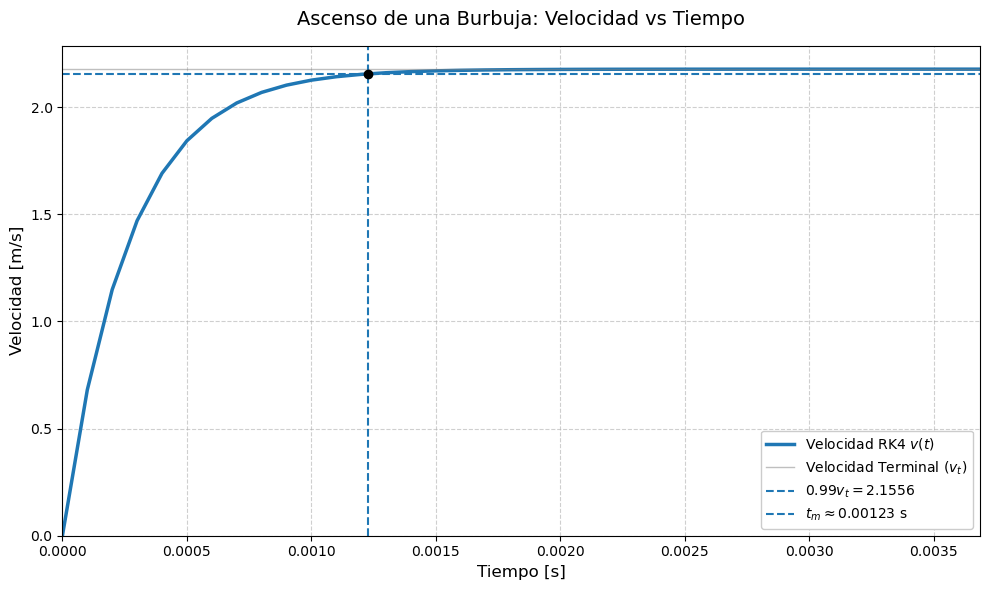

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# 1. Parámetros del problema (Corregidos)
# ==========================================
r = 1e-3         # Radio de la burbuja [m]
mu = 1e-3        # Viscosidad dinámica del agua [Pa s]
rho_liq = 1000.  # Densidad del agua [kg/m^3]
rho_air = 1.2    # Densidad del aire [kg/m^3]
g = 9.81         # Gravedad [m/s^2]

t_start = 0.0    # Tiempo inicial [s]
t_end = 0.5      # Tiempo final [s]
h = 1e-4         # Tamaño de paso [s]

# ==========================================
# 2. Definición de la ODE y Velocidad Terminal
# ==========================================
# Ecuación diferencial: dv/dt = A - B*v
A = g * (rho_liq - rho_air) / rho_air
B = (9 * mu) / (2 * rho_air * r**2)

def dv_dt(v):
    """Retorna la aceleración (dv/dt) para una velocidad dada."""
    return A - B * v

# La velocidad terminal teórica se alcanza cuando dv/dt = 0  =>  A - B*vt = 0
v_terminal = A / B
v_target = 0.99 * v_terminal

print("-" * 50)
print(f"Velocidad terminal (v_t) : {v_terminal:.5f} m/s")
print(f"Objetivo (99% de v_t)    : {v_target:.5f} m/s")
print("-" * 50)

# ==========================================
# 3. Solución de la ODE con RK4
# ==========================================
def rk4_step(v_curr, step_size):
    """Calcula un paso individual del método RK4."""
    k1 = step_size * dv_dt(v_curr)
    k2 = step_size * dv_dt(v_curr + k1/2)
    k3 = step_size * dv_dt(v_curr + k2/2)
    k4 = step_size * dv_dt(v_curr + k3)
    return v_curr + (k1 + 2*k2 + 2*k3 + k4) / 6

def get_v_at_t(t_target):
    """
    Integra la ODE desde t=0 hasta t_target usando RK4 para poder 
    evaluar cualquier instante de tiempo continuo en la bisección.
    """
    t = 0.0
    v = 0.0
    
    # Dar pasos completos de tamaño h
    while t + h <= t_target:
        v = rk4_step(v, h)
        t += h
        
    # Dar un paso fraccionario si t_target no es múltiplo exacto de h
    if t < t_target:
        step_fraccion = t_target - t
        v = rk4_step(v, step_fraccion)
        
    return v

# Ejecutamos RK4 a lo largo del span de tiempo para encontrar dónde ocurre el cruce
t_values = np.arange(t_start, t_end + h, h)
v_values = np.zeros(len(t_values))

t_left, t_right = None, None

for i in range(1, len(t_values)):
    v_values[i] = rk4_step(v_values[i-1], h)
    
    # Detectamos el intervalo [t_left, t_right] donde cruza el 99% de v_t
    if v_values[i-1] < v_target and v_values[i] >= v_target and t_left is None:
        t_left = t_values[i-1]
        t_right = t_values[i]

if t_left is None:
    print("La burbuja no alcanzó el 99% de la velocidad terminal en el tiempo simulado.")
    t_exacto = None
else:
    print(f"El cruce ocurre en el intervalo de RK4: [{t_left:.5f} s, {t_right:.5f} s]")

    # ==========================================
    # 4. Método de Bisección
    # ==========================================
    # Buscamos la raíz de la función f(t) = v(t) - v_target
    def f_root(t):
        return get_v_at_t(t) - v_target

    # Inicializamos los límites de la bisección
    t_a = t_left
    t_b = t_right
    tol = 1e-10  # Tolerancia muy estricta para el tiempo exacto
    iteraciones = 0
    
    # Lista para guardar los datos de la tabla
    datos_iteraciones = []

    while (t_b - t_a) / 2.0 > tol:
        t_m = (t_a + t_b) / 2.0
        
        eval_m = f_root(t_m)
        
        # Guardar registro de la iteración
        datos_iteraciones.append({
            'Iteración': iteraciones,
            't_a': t_a,
            't_b': t_b,
            't_m': t_m,
            'f(t_m)': eval_m
        })
        
        if eval_m == 0:
            break # Raíz exacta encontrada
        elif f_root(t_a) * eval_m < 0:
            t_b = t_m # La raíz está en la mitad izquierda
        else:
            t_a = t_m # La raíz está en la mitad derecha
            
        iteraciones += 1

    t_exacto = (t_a + t_b) / 2.0

    # Formatear e imprimir tabla estilo DataFrame (Pandas)
    df_tabla = pd.DataFrame(datos_iteraciones)
    df_tabla['t_a'] = df_tabla['t_a'].apply(lambda x: f'{x:.8f}')
    df_tabla['t_b'] = df_tabla['t_b'].apply(lambda x: f'{x:.8f}')
    df_tabla['t_m'] = df_tabla['t_m'].apply(lambda x: f'{x:.8f}')
    df_tabla['f(t_m)'] = df_tabla['f(t_m)'].apply(lambda x: f'{x:.8e}')
    
    print("\n" + "="*68)
    print("        TABLA DE ITERACIONES - MÉTODO DE BISECCIÓN")
    print("="*68)
    print(df_tabla.to_string(index=False))

    print("-" * 50)
    print(f"Instante exacto hallado por bisección (tm) : {t_exacto:.6f} s")
    print(f"Iteraciones de bisección requeridas        : {iteraciones}")
    print("-" * 50)

# ==========================================
# 5. Gráfica de los resultados
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(t_values, v_values, label='Velocidad RK4 $v(t)$', color='#1f77b4', linewidth=2.5)
plt.axhline(v_terminal, color='gray', linestyle='-', linewidth=1.0, alpha=0.5, label='Velocidad Terminal ($v_t$)')

if t_exacto is not None:
    # Líneas cruzadas ("crosshair") al estilo de tus compañeros
    plt.axhline(v_target, color='#1f77b4', linestyle='--', linewidth=1.5, label=f'$0.99 v_t = {v_target:.4f}$')
    plt.axvline(t_exacto, color='#1f77b4', linestyle='--', linewidth=1.5, label=f'$t_m \\approx {t_exacto:.5f}$ s')
    
    plt.plot(t_exacto, v_target, 'ko', markersize=6, zorder=5)
    # Limitamos el eje X para hacer zoom en la parte donde la velocidad cambia,
    # ya que de lo contrario se vería como un salto vertical inmediato en el lapso de 0.5s
    plt.xlim(0, t_exacto * 3)
    plt.ylim(0, v_terminal * 1.05)
else:
    plt.xlim(t_start, t_end)

plt.title('Ascenso de una Burbuja: Velocidad vs Tiempo', fontsize=14, pad=15)
plt.xlabel('Tiempo [s]', fontsize=12)
plt.ylabel('Velocidad [m/s]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', framealpha=1.0)
plt.tight_layout()
plt.show()